### EXPLANATORY DATA ANALYSIS: CLEANING AND UNDERSTANDING THE DATA

In [65]:
# Import necessary libraries
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns


### Load the data
Read `train.csv` and `test.csv` from `data/raw/`. `train.csv` has the `anomaly` label, `test.csv` doesn't, that's what we're predicting. Peek at the first few rows to confirm everything loaded correctly.

In [66]:
# Load the train and test data
data_dir = Path.cwd().parent /"data"/"raw"
train_data = pd.read_csv(data_dir/"train.csv")
test_data = pd.read_csv(data_dir/"test.csv")

dir_to_save = Path.cwd().parent /"reports"/"figures"

train_data.head()

,id,anomaly,channel,sampling,duration,len,mean,var,std,kurtosis,...,smooth10_n_peaks,smooth20_n_peaks,diff_peaks,diff2_peaks,diff_var,diff2_var,gaps_squared,len_weighted,var_div_duration,var_div_len
0,2,1,CADC0872,1,476,477,-3.639396e-06,6.476485e-10,0.000025,-1.243611,...,1,1,5,8,1.489383e-12,3.004752e-12,476,477,1.360606e-12,1.357754e-12
1,3,1,CADC0872,1,594,595,1.170788e-05,5.592877e-10,0.000024,-0.284593,...,2,2,2,3,4.112280e-12,1.029918e-11,594,595,9.415618e-13,9.399794e-13
2,4,1,CADC0872,1,271,272,8.486808e-07,5.466024e-10,0.000023,-0.887088,...,2,2,3,6,2.475760e-11,6.240985e-11,271,272,2.016983e-12,2.009568e-12
3,5,0,CADC0872,1,256,257,1.058485e-05,5.279023e-10,0.000023,-1.484393,...,1,1,78,87,5.547101e-13,7.035422e-13,256,257,2.062118e-12,2.054094e-12
4,7,0,CADC0872,1,379,380,2.990795e-06,3.843725e-10,0.000020,-0.736379,...,1,1,111,127,3.793821e-13,6.807879e-13,379,380,1.014176e-12,1.011507e-12


Same peek, but for the test set. Confirms it has the same columns minus `anomaly`.

In [67]:
test_data.head()

,id,channel,sampling,duration,len,mean,var,std,kurtosis,skew,...,smooth10_n_peaks,smooth20_n_peaks,diff_peaks,diff2_peaks,diff_var,diff2_var,gaps_squared,len_weighted,var_div_duration,var_div_len
0,1,CADC0872,1,279,280,8.533143e-07,3.494283e-10,0.000019,0.631117,0.552052,...,3,2,4,6,1.271176e-10,2.960666e-10,279,280,1.252431e-12,1.247958e-12
1,6,CADC0872,1,252,253,6.326025e-06,6.643180e-10,0.000026,-1.302309,-0.179240,...,1,1,66,84,6.430575e-13,7.268033e-13,252,253,2.636182e-12,2.625763e-12
2,19,CADC0872,1,202,203,-5.584398e-06,1.926298e-10,0.000014,-1.264922,-0.146844,...,1,1,29,40,2.359944e-12,5.479548e-12,202,203,9.536128e-13,9.489152e-13
3,22,CADC0872,1,183,184,-5.040149e-06,2.295797e-10,0.000015,0.537473,-1.509396,...,1,1,14,15,7.517321e-12,1.572588e-11,183,184,1.254534e-12,1.247716e-12
4,27,CADC0872,1,202,203,7.010658e-06,5.013481e-10,0.000022,-0.833690,-0.478957,...,1,1,36,38,3.289437e-12,7.773532e-12,202,203,2.481921e-12,2.469695e-12


In [68]:
print("=================== SHAPE OF THE TRAIN AND TEST DATA ===========================================")
print("train:", train_data.shape, "test:", test_data.shape)

=================== SHAPE OF THE TRAIN AND TEST DATA ===========================================
train: (1698, 22) test: (425, 21)


### Shape check
How many rows and columns in each file. Train has 1,698 rows, test has 425. Matches what the competition description said, so no rows got dropped or duplicated on load.

In [69]:
print("==================== COLUMNS OF THE TRAIN DATA   ===========================================")
print("train:", train_data.columns.to_list())
print("==================== COLUMNS OF THE TEST DATA   ===========================================")
print("test:", test_data.columns.to_list())

==================== COLUMNS OF THE TRAIN DATA   ===========================================
train: ['id', 'anomaly', 'channel', 'sampling', 'duration', 'len', 'mean', 'var', 'std', 'kurtosis', 'skew', 'n_peaks', 'smooth10_n_peaks', 'smooth20_n_peaks', 'diff_peaks', 'diff2_peaks', 'diff_var', 'diff2_var', 'gaps_squared', 'len_weighted', 'var_div_duration', 'var_div_len']
==================== COLUMNS OF THE TEST DATA   ===========================================
test: ['id', 'channel', 'sampling', 'duration', 'len', 'mean', 'var', 'std', 'kurtosis', 'skew', 'n_peaks', 'smooth10_n_peaks', 'smooth20_n_peaks', 'diff_peaks', 'diff2_peaks', 'diff_var', 'diff2_var', 'gaps_squared', 'len_weighted', 'var_div_duration', 'var_div_len']


### Column check
List out the columns in both files side by side. Confirms `test.csv` is missing only the `anomaly` column and nothing else is different.

In [70]:
train_data.describe()

,id,anomaly,sampling,duration,len,mean,var,std,kurtosis,skew,...,smooth10_n_peaks,smooth20_n_peaks,diff_peaks,diff2_peaks,diff_var,diff2_var,gaps_squared,len_weighted,var_div_duration,var_div_len
count,1698.000000,1698.000000,1698.000000,1698.000000,1698.000000,1.698000e+03,1.698000e+03,1698.000000,1698.000000,1698.000000,...,1698.000000,1698.000000,1698.000000,1698.000000,1.698000e+03,1.698000e+03,1698.000000,1698.000000,1.698000e+03,1.698000e+03
mean,1057.777974,0.204358,3.480565,263.828622,144.236749,1.104564e-01,3.059109e-02,0.096073,-1.081795,0.183791,...,1.111307,1.184335,18.423439,25.647232,9.578727e-04,1.159623e-03,992.262073,266.053004,1.192246e-04,4.360958e-04
std,612.131692,0.403351,1.941978,165.177323,152.852668,1.956567e-01,5.487614e-02,0.146197,1.066588,0.528493,...,0.397371,0.426925,29.402582,33.366182,4.519551e-03,1.228734e-02,1610.803606,164.436226,2.157167e-04,8.907386e-04
min,2.000000,0.000000,1.000000,35.000000,8.000000,-3.833030e-05,1.422763e-11,0.000004,-1.858813,-1.423206,...,1.000000,0.000000,0.000000,0.000000,1.962330e-13,3.875356e-13,104.000000,40.000000,2.817267e-14,4.404840e-14
25%,532.250000,0.000000,1.000000,175.000000,40.000000,-7.550977e-07,2.948776e-10,0.000017,-1.452319,-0.113285,...,1.000000,1.000000,1.000000,4.000000,3.093149e-12,1.203108e-12,289.250000,176.000000,1.296766e-12,2.775930e-12
50%,1057.500000,0.000000,5.000000,225.000000,70.000000,4.238440e-06,6.082591e-10,0.000025,-1.309258,0.009403,...,1.000000,1.000000,5.000000,14.000000,3.631234e-11,1.124900e-11,500.000000,230.000000,3.759460e-12,1.548166e-11
75%,1583.750000,0.000000,5.000000,325.000000,204.000000,2.048282e-01,3.720200e-02,0.192878,-1.006474,0.551745,...,1.000000,1.000000,22.000000,32.000000,2.967331e-04,1.436372e-04,1175.000000,325.000000,1.882478e-04,4.792335e-04
max,2123.000000,1.000000,5.000000,1335.000000,1040.000000,1.118632e+00,2.724801e-01,0.521996,31.201842,4.374560,...,5.000000,4.000000,240.000000,256.000000,9.987869e-02,3.033986e-01,20750.000000,1340.000000,1.686516e-03,8.031028e-03


### Summary statistics: train
Min, max, mean, quartiles for every numeric column. Good for spotting obvious problems early, things like impossible negative variances, one column stuck at a constant value, or wildly different scales between features (which matters later for models like logistic regression).

In [71]:
test_data.describe()

,id,sampling,duration,len,mean,var,std,kurtosis,skew,n_peaks,smooth10_n_peaks,smooth20_n_peaks,diff_peaks,diff2_peaks,diff_var,diff2_var,gaps_squared,len_weighted,var_div_duration,var_div_len
count,425.000000,425.000000,425.000000,425.000000,4.250000e+02,4.250000e+02,425.000000,425.000000,425.000000,425.000000,425.000000,425.000000,425.000000,425.000000,4.250000e+02,4.250000e+02,425.000000,425.000000,4.250000e+02,4.250000e+02
mean,1078.868235,3.607059,272.745882,137.832941,1.130107e-01,3.092875e-02,0.096835,-1.100269,0.142629,1.564706,1.105882,1.171765,16.861176,23.844706,7.518828e-04,5.912720e-04,1027.061176,275.404706,1.111407e-04,4.363300e-04
std,616.900589,1.907890,174.869713,150.291518,1.991504e-01,5.511705e-02,0.146978,0.676009,0.531932,2.482234,0.407000,0.419066,27.287291,30.090420,2.517628e-03,5.619598e-03,1370.147226,173.283784,1.961775e-04,8.604892e-04
min,1.000000,1.000000,40.000000,9.000000,-3.378029e-05,3.545022e-11,0.000006,-1.689038,-1.509396,1.000000,0.000000,0.000000,1.000000,0.000000,2.288867e-13,4.347120e-13,122.000000,45.000000,3.743965e-14,1.252658e-13
25%,530.000000,1.000000,171.000000,42.000000,-6.566486e-07,3.161872e-10,0.000018,-1.439216,-0.142113,1.000000,1.000000,1.000000,2.000000,5.000000,3.479538e-12,1.349150e-12,325.000000,172.000000,1.345753e-12,3.034260e-12
50%,1080.000000,5.000000,225.000000,70.000000,5.600304e-06,5.903700e-10,0.000024,-1.276686,-0.009230,1.000000,1.000000,1.000000,5.000000,13.000000,3.998717e-11,1.024830e-11,550.000000,230.000000,3.903263e-12,1.571417e-11
75%,1617.000000,5.000000,350.000000,190.000000,2.048790e-01,4.023657e-02,0.200591,-0.964603,0.518854,1.000000,1.000000,1.000000,19.000000,31.000000,3.096911e-04,1.299745e-04,1250.000000,354.000000,1.906669e-04,4.036315e-04
max,2121.000000,5.000000,1070.000000,915.000000,9.788371e-01,2.656469e-01,0.515409,8.145685,2.997559,34.000000,5.000000,4.000000,234.000000,252.000000,4.065777e-02,1.076492e-01,19176.000000,1075.000000,1.130412e-03,5.534310e-03


Same summary, but for test. Compare it against the train summary above, the ranges should look similar. If test values are way outside the train range on some feature, that's a sign the model might not generalize well on that feature.

In [72]:
print("=================== MISSING VALUES =======================")
print("train:", train_data.isna().sum().sum())
print("test:", test_data.isna().sum().sum())

=================== MISSING VALUES =======================
train: 0
test: 0


### Missing values
Count of NaNs in each dataset. Zero missing values in both, so no imputation needed anywhere in this pipeline.

In [73]:
print("=================== DUPLICATED VALUES =======================")
print("train:", train_data[train_data.duplicated()])
print("test:", test_data[test_data.duplicated()])

=================== DUPLICATED VALUES =======================
train: Empty DataFrame
Columns: [id, anomaly, channel, sampling, duration, len, mean, var, std, kurtosis, skew, n_peaks, smooth10_n_peaks, smooth20_n_peaks, diff_peaks, diff2_peaks, diff_var, diff2_var, gaps_squared, len_weighted, var_div_duration, var_div_len]
Index: []

[0 rows x 22 columns]
test: Empty DataFrame
Columns: [id, channel, sampling, duration, len, mean, var, std, kurtosis, skew, n_peaks, smooth10_n_peaks, smooth20_n_peaks, diff_peaks, diff2_peaks, diff_var, diff2_var, gaps_squared, len_weighted, var_div_duration, var_div_len]
Index: []

[0 rows x 21 columns]


### Duplicate rows
Check for exact duplicate rows in train and test. If any show up, they'd need a decision: drop them, or leave them since they might be legitimately repeated readings.

In [74]:
print("===================== Correlation with target ============================")
num_cols = [c for c in train_data.columns if c not in ["id", "anomaly", "channel"]]
corr = train_data[num_cols + ["anomaly"]].corr()["anomaly"].drop("anomaly")
print(corr.sort_values(key=abs, ascending=False))

===================== Correlation with target ============================
smooth10_n_peaks    0.530805
len                 0.294391
sampling           -0.262369
kurtosis            0.231592
duration            0.188388
var                -0.178806
len_weighted        0.172065
n_peaks             0.167848
std                -0.166153
diff2_var           0.159200
diff2_peaks        -0.157784
mean               -0.154144
diff_peaks         -0.153135
var_div_duration   -0.151955
smooth20_n_peaks    0.137004
gaps_squared        0.128388
diff_var            0.120365
var_div_len        -0.113268
skew               -0.000302
Name: anomaly, dtype: float64


### Correlation with the target
Pearson correlation of every numeric feature against `anomaly`, sorted by strength. This is the first signal for which features actually matter. `smooth10_n_peaks` comes out strongest, `skew` comes out basically useless (near zero).

Note: this only catches straight-line relationships. A feature could still matter a lot through a nonlinear pattern and show a weak correlation here, that's what the boxplots later help catch.

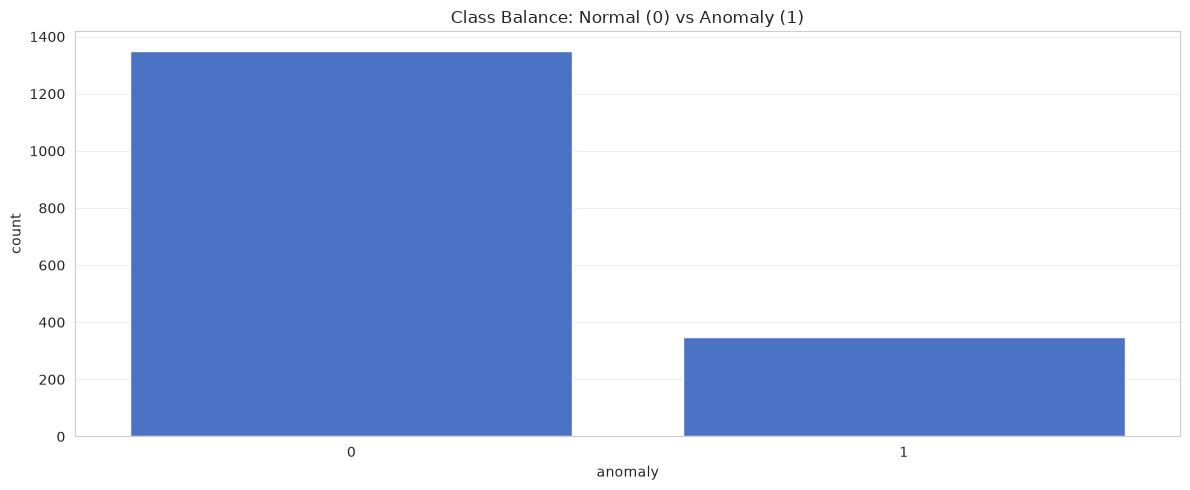

In [75]:
sns.set_style("whitegrid")
num_cols = [c for c in train_data.columns if c not in ["id", "anomaly", "channel"]]
# --- 1. Class balance ---
plt.figure(figsize=(12, 5))
sns.countplot(x="anomaly", data=train_data)
plt.title("Class Balance: Normal (0) vs Anomaly (1)")
plt.xlabel("anomaly")
plt.ylabel("count")
plt.tight_layout()
plt.savefig(dir_to_save/"plot_class_balance.png", dpi=150)
plt.show()


### Plot 1: Class balance
Bar chart of how many normal (0) vs anomalous (1) segments there are. This is the visual version of the ~20% anomaly rate, and it's the reason the competition scores on F1 instead of accuracy: a model that predicts "normal" every time would look good on accuracy but be useless.

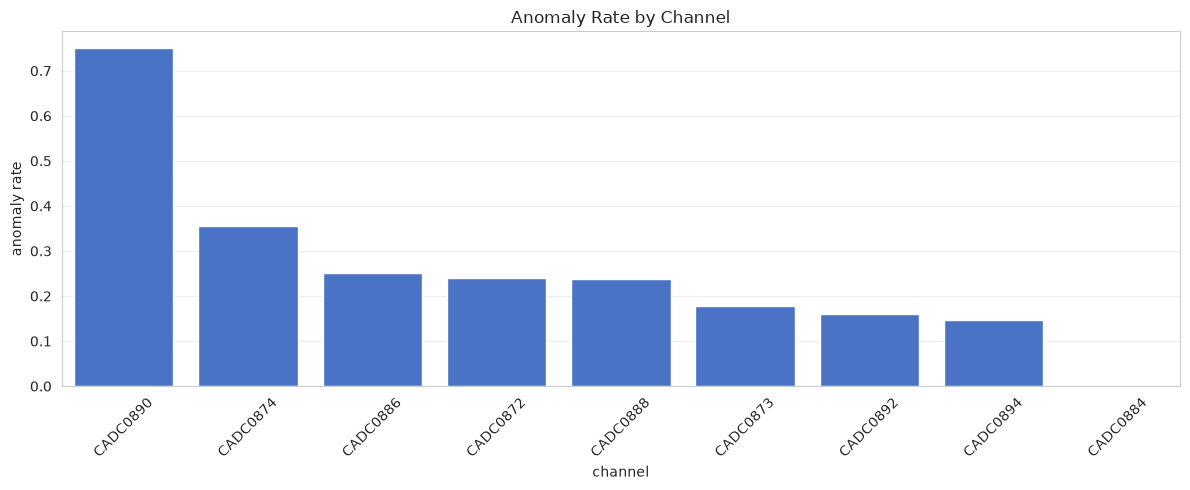

In [76]:
# --- 2. Anomaly rate per channel ---
channel_rates = train_data.groupby("channel")["anomaly"].mean().sort_values(ascending=False)
plt.figure(figsize=(12, 5))
sns.barplot(x=channel_rates.index, y=channel_rates.values)
plt.title("Anomaly Rate by Channel")
plt.xlabel("channel")
plt.ylabel("anomaly rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(dir_to_save/"plot_channel_rates.png", dpi=150)
plt.show()

### Plot 2: Anomaly rate by channel
Anomaly rate for each of the 9 channels, sorted highest to lowest. Some channels almost never have anomalies, others have them much more often. That's a strong signal that `channel` itself is informative, on top of whatever the numeric features say, and a model should be given channel as a feature.

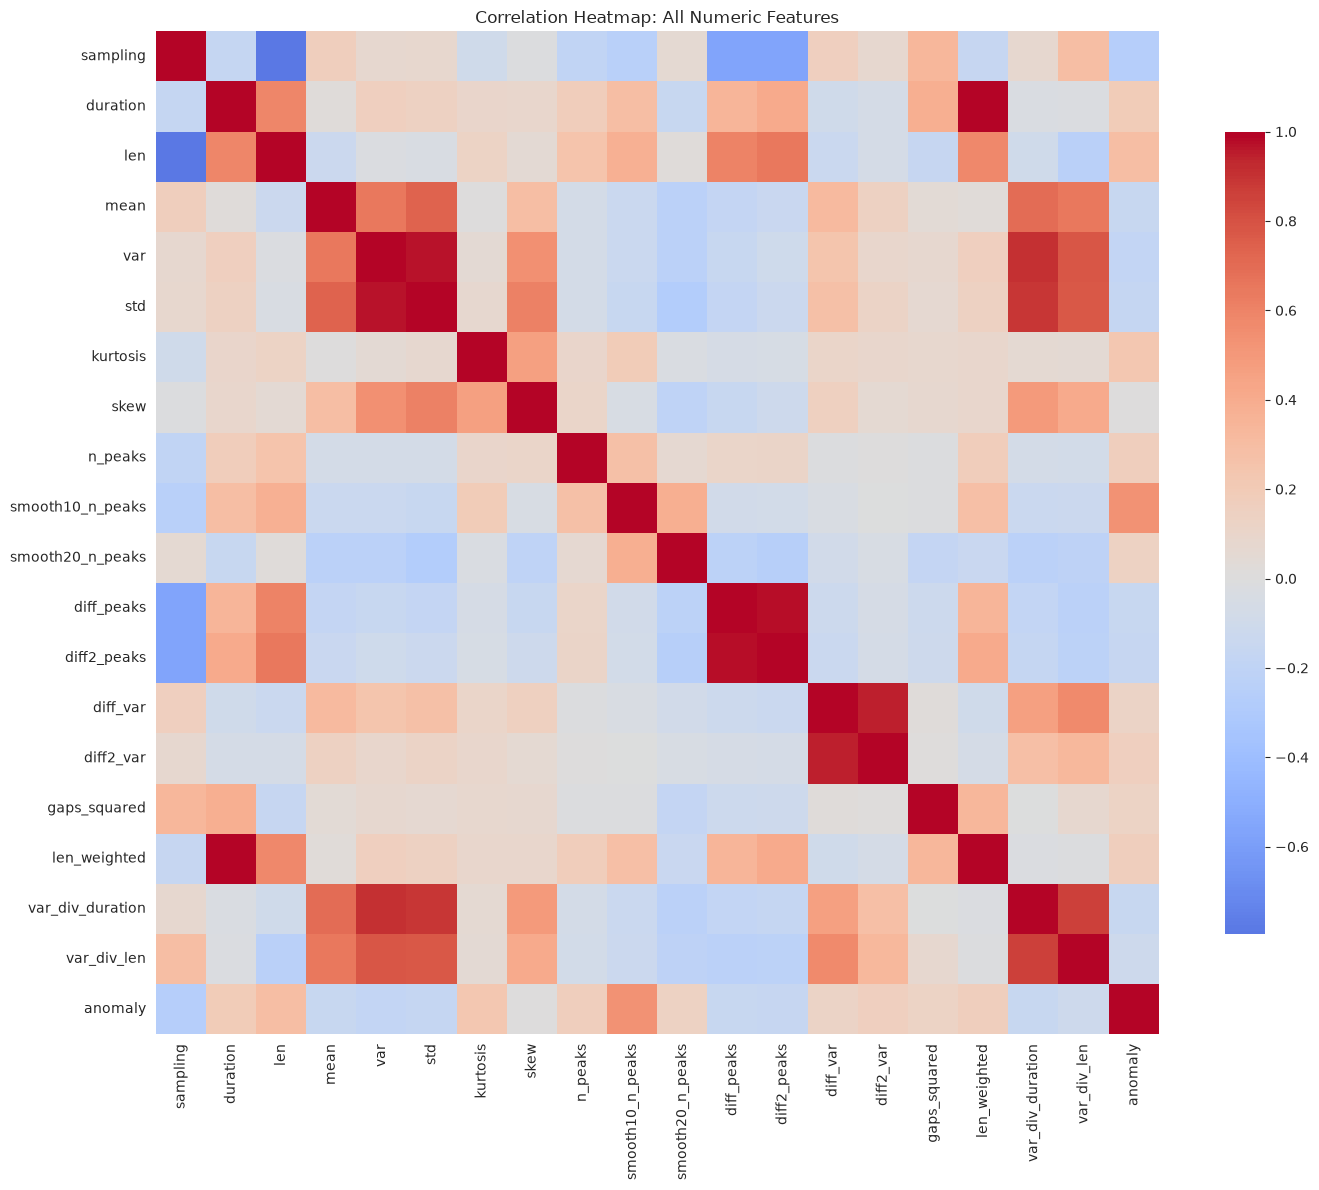

In [77]:
# --- 3. Correlation heatmap (numeric features + target) ---
corr = train_data[num_cols + ["anomaly"]].corr()
plt.figure(figsize=(15, 12))
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0, square=True,
            cbar_kws={"shrink": 0.8})
plt.title("Correlation Heatmap: All Numeric Features")
plt.tight_layout()
plt.savefig(dir_to_save/"plot_corr_heatmap.png", dpi=150)
plt.show()


### Plot 3: Correlation heatmap
Every numeric feature plotted against every other one. Look for dark red or dark blue blocks, those are groups of features that move together and are partly redundant (for example the variance-related features). Useful for deciding what to drop or combine if a simpler model needs fewer, less-overlapping inputs.

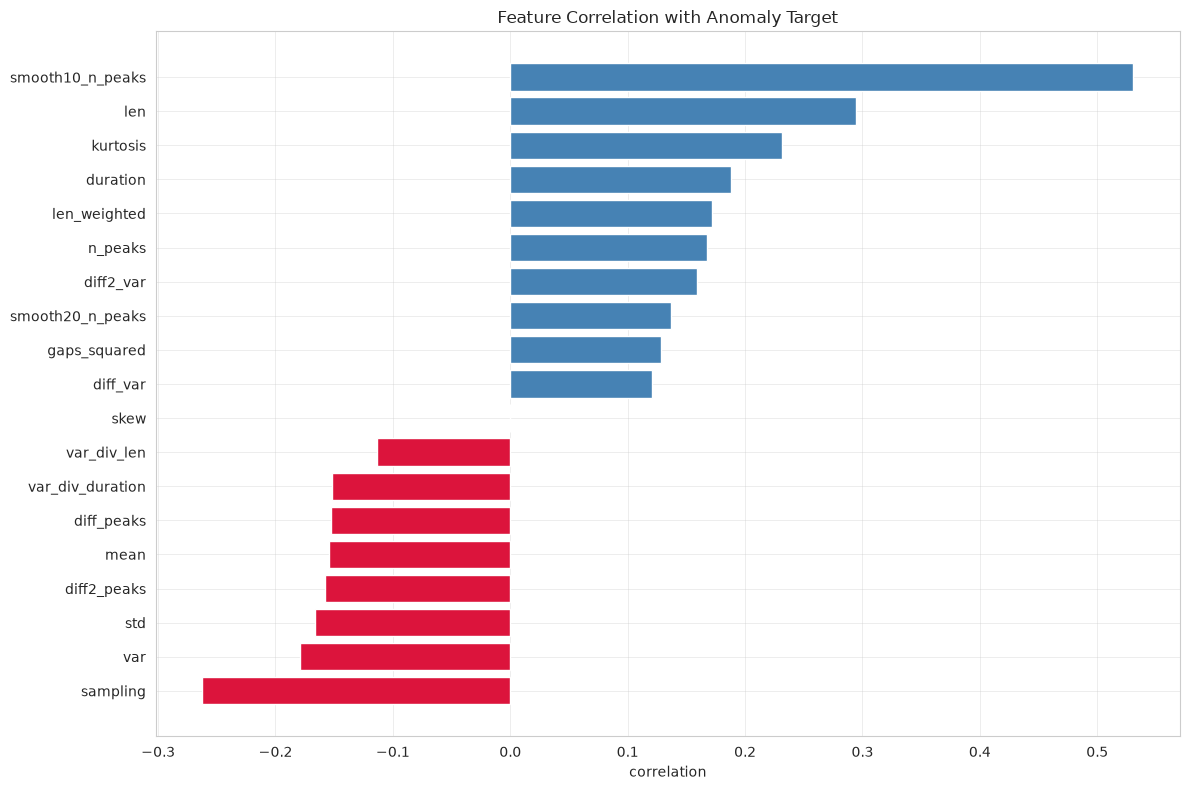

In [78]:
# --- 4. Correlation with target only, sorted, as a horizontal bar chart ---
target_corr = corr["anomaly"].drop("anomaly").sort_values()
plt.figure(figsize=(12, 8))
colors = ["crimson" if v < 0 else "steelblue" for v in target_corr.values]
plt.barh(target_corr.index, target_corr.values, color=colors)
plt.title("Feature Correlation with Anomaly Target")
plt.xlabel("correlation")
plt.tight_layout()
plt.savefig(dir_to_save/"plot_target_corr.png", dpi=150)
plt.show()

### Plot 4: Correlation with target, visualized
Same numbers as the printed correlation table earlier, but as a horizontal bar chart, sorted, colored by direction. Easier to scan at a glance and better for including in a report or slide than a printed table.

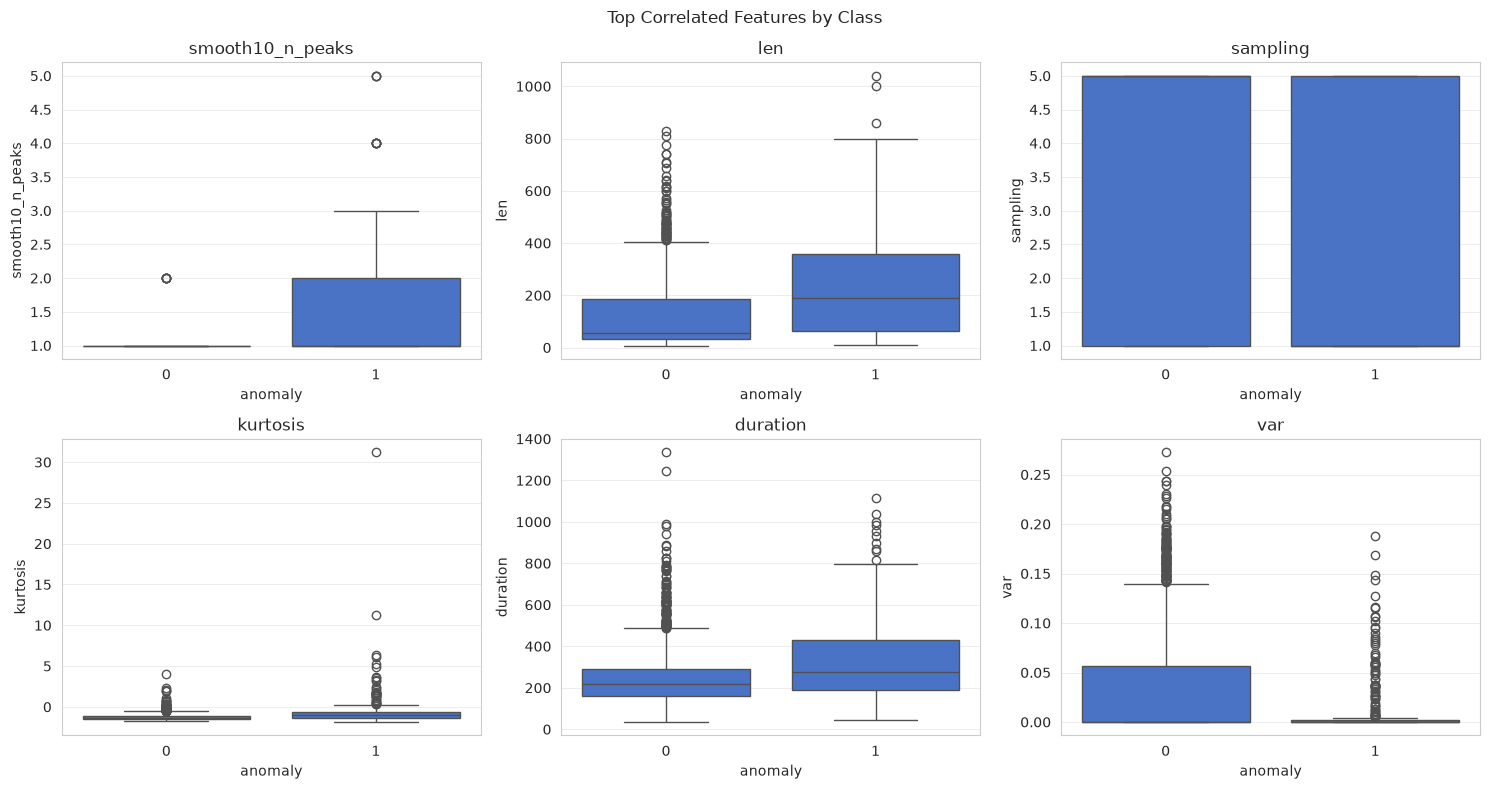

In [79]:
# --- 5. Distribution of top features, split by class ---
top_features = target_corr.abs().sort_values(ascending=False).head(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.flatten(), top_features):
    sns.boxplot(x="anomaly", y=feat, data=train_data, ax=ax)
    ax.set_title(feat)
plt.suptitle("Top Correlated Features by Class")
plt.tight_layout()
plt.savefig(dir_to_save/"plot_top_features_boxplots.png", dpi=150)
plt.show()

### Plot 5: Top features split by class
Boxplots of the 6 features most correlated with `anomaly`, comparing their distributions for normal vs anomalous segments. This is where you can actually see whether a feature separates the two classes (distinct boxes) or overlaps heavily (not very useful on its own).

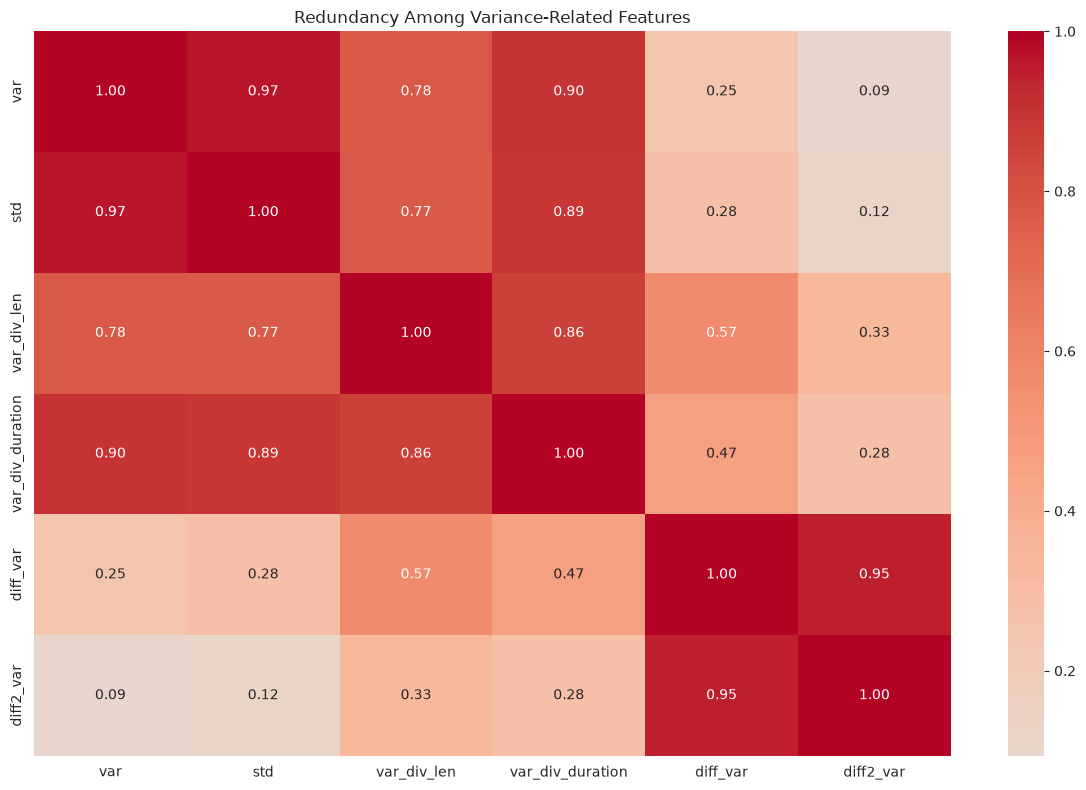

In [80]:
# --- 6. Redundancy check among variance-related features ---
var_cols = ["var", "std", "var_div_len", "var_div_duration", "diff_var", "diff2_var"]
plt.figure(figsize=(12, 8))
sns.heatmap(train_data[var_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Redundancy Among Variance-Related Features")
plt.tight_layout()
plt.savefig(dir_to_save/"plot_redundancy.png", dpi=150)
plt.show()

### Plot 6: Redundancy among variance features
Focused heatmap on just the variance-family features (`var`, `std`, `var_div_len`, `var_div_duration`, `diff_var`, `diff2_var`). These are mathematically related to each other, so this confirms how much overlap there is and whether keeping all of them adds real information or just noise for a model to overfit on.